# Principal Component Analysis (PCA) - Lung Cancer Dataset

A comprehensive step-by-step tutorial on Principal Component Analysis for dimensionality reduction.

## Learning Objectives
- Understand PCA concepts and theory
- Learn feature scaling importance
- Apply PCA to real-world dataset
- Interpret PCA results
- Visualize high-dimensional data

## Step 1: Import Libraries

In [ ]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Machine learning and preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load Data

We'll load the UCI Lung Cancer Dataset which contains:
- 32 patient records
- 14 medical features
- 1 target variable (Cancer/No Cancer)

In [ ]:
# Dataset URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/lung-cancer/lung-cancer.data'

In [ ]:
# Define column names
column_names = ['Class', 'Age', 'Smoking', 'Yellow_Fingers', 'Anxiety',
                'Peer_Pressure', 'Chronic_Diseases', 'Fatigue', 'Allergy',
                'Wheezing', 'Alcohol_Consuming', 'Coughing', 'Shortness_of_Breath',
                'Swallowing_Difficulty', 'Chest_Pain']

In [ ]:
# Load data
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/lung-cancer/lung-cancer.data', header=None, names=column_names)

print(f"✓ Dataset loaded successfully!")

✓ Dataset loaded successfully!


In [ ]:
df.shape

(32, 15)

In [ ]:
df.head()

Class  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1      2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2      1   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1      2   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2      1   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 2 2 1 1 1 3 2 1 2 2 1 2 2 2      1   

                                                                                     Age  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1    2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2    2   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1    2   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2    2   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 2 2 1 1 1 3 2 1 2 2 1 2 2 2    2   

                                                                                     Smoking  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1        2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2        2   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1        1   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2        2   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 2 2 1 1 1 3 2 1 2 2 1 2 2 2        2   

                                                                                     Yellow_Fingers  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1               2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2               1   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1               2   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2               2   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 2 2 1 1 1 3 2 1 2 2 1 2 2 2               2   

                                                                                     Anxiety  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1        2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2        2   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1        2   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2        1   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 2 2 1 1 1 3 2 1 2 2 1 2 2 2        2   

                                                                                     Peer_Pressure  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1              2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2              2   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1              2   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2              2   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 2 2 1 1 1 3 2 1 2 2 1 2 2 2              2   

                                                                                     Chronic_Diseases  \
1 0 3 0 ? 0 2 2 2 1 1 1 1 3 2 2 1 2 2 0 2 2 2 2 1 2 2 2 3 2 1 1 1 3 3 2 2 1 2 2 2 1                 2   
      3 1 0 3 1 3 1 1 1 1 1 3 3 1 2 2 0 0 2 2 2 1 2 1 3 2 3 1 1 1 3 3 2 2 2 1 2 2 2                 2   
        2 0 3 3 3 1 1 1 0 3 3 3 1 2 1 0 0 2 2 2 1 2 2 3 2 3 1 3 3 3 1 2 2 1 2 2 2 1                 2   
    2 3 2 1 3 3 3 1 2 1 0 3 3 1 1 2 2 0 0 2 2 2 2 1 3 2 3 3 1 3 3 3 1 1 1 1 2 2 2 2                 2   
    3 2 1 1 3 3 3 2 2 2 1 1 2 2 2 2 2 0 0 2 2 2 1 1 2 3 

## Step 3: Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 32 entries, (np.int64(1), np.int64(0), np.int64(3), np.int64(0), '?', np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(3), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(2), np.int64(2), np.int64(1), '2', np.int64(2), np.int64(2), np.int64(1)) to (np.int64(3), np.int64(0), np.int64(2), np.int64(3), '1', np.int64(0), np.int64(2), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64

In [ ]:
df.describe()

,Class,Age,Smoking,Yellow_Fingers,Anxiety,Peer_Pressure,Chronic_Diseases,Fatigue,Allergy,Wheezing,Alcohol_Consuming,Coughing,Shortness_of_Breath,Swallowing_Difficulty,Chest_Pain
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,1.750000,2.062500,1.875000,1.968750,1.937500,2.062500,2.062500,2.000000,2.000000,2.000000,1.843750,1.843750,1.562500,1.812500,1.718750
std,0.622171,0.353553,0.491869,0.400353,0.435335,0.245935,0.245935,0.359211,0.359211,0.508001,0.447889,0.447889,0.504016,0.396558,0.456803
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000


In [ ]:
df.isnull().sum()

,0
Class,0
Age,0
Smoking,0
Yellow_Fingers,0
Anxiety,0
Peer_Pressure,0
Chronic_Diseases,0
Fatigue,0
Allergy,0
Wheezing,0


## Step 4: Data Cleaning

Handle missing values (marked as '?') and convert to numeric types.

In [ ]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

In [ ]:
# Convert to numeric
for col in df.columns:
    if col != 'Class':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values after replacement:")
print(df.isnull().sum())

Missing values after replacement:
Class                    0
Age                      0
Smoking                  0
Yellow_Fingers           0
Anxiety                  0
Peer_Pressure            0
Chronic_Diseases         0
Fatigue                  0
Allergy                  0
Wheezing                 0
Alcohol_Consuming        0
Coughing                 0
Shortness_of_Breath      0
Swallowing_Difficulty    0
Chest_Pain               0
dtype: int64


In [ ]:
# Drop rows with NaN
df_clean = df.dropna()

In [ ]:
print(f"\n✓ Data cleaned!")
print(f"Removed: {len(df) - len(df_clean)} rows")
print(f"Final shape: {df_clean.shape}")


✓ Data cleaned!
Removed: 0 rows
Final shape: (32, 15)


## Step 5: Separate Features and Target

In [ ]:
# Dependent variable (Target)
y = df_clean['Class']

In [ ]:
# Independent variables (Features)
X = df_clean.drop('Class', axis=1)

In [ ]:
print("Target variable distribution:")
print(y.value_counts())

Target variable distribution:
Class
2    18
1    11
3     3
Name: count, dtype: int64


In [ ]:
print(f"\nFeatures shape: {X.shape}")
print(f"Features: {list(X.columns)}")


Features shape: (32, 14)
Features: ['Age', 'Smoking', 'Yellow_Fingers', 'Anxiety', 'Peer_Pressure', 'Chronic_Diseases', 'Fatigue', 'Allergy', 'Wheezing', 'Alcohol_Consuming', 'Coughing', 'Shortness_of_Breath', 'Swallowing_Difficulty', 'Chest_Pain']


## Step 6: Feature Scaling

**WHY SCALING IS CRITICAL FOR PCA:**

PCA finds directions of maximum variance. If features have different scales:
- Features with larger ranges dominate
- Results become biased
- Interpretation becomes unreliable

Solution: StandardScaler (Z-score normalization)
- Mean of each feature becomes 0
- Standard deviation becomes 1
- All features on same scale

In [ ]:
print("BEFORE SCALING:")
print(f"Mean: {X.mean().mean():.4f}")
print(f"Std Dev: {X.std().mean():.4f}")
print(f"Min: {X.min().min():.4f}")
print(f"Max: {X.max().max():.4f}")

BEFORE SCALING:
Mean: 1.9107
Std Dev: 0.4038
Min: 1.0000
Max: 3.0000


In [ ]:
# Initialize and fit StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
print("\nAFTER SCALING:")
print(f"Mean: {X_scaled_df.mean().mean():.6f}")
print(f"Std Dev: {X_scaled_df.std().mean():.4f}")
print(f"Min: {X_scaled_df.min().min():.4f}")
print(f"Max: {X_scaled_df.max().max():.4f}")


AFTER SCALING:
Mean: -0.000000
Std Dev: 1.0160
Min: -3.0533
Max: 3.8730


## Step 7: Apply PCA - Explained Variance Analysis

First, fit PCA with all components to understand how much variance each captures.

In [ ]:
# Apply PCA with all components
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

In [ ]:
# Calculate cumulative explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [ ]:
print(f"Total components: {len(pca_full.components_)}")
print(f"\nExplained variance by component:")
for i in range(min(5, len(explained_variance))):
    print(f"PC{i+1}: {explained_variance[i]*100:.2f}%")

Total components: 14

Explained variance by component:
PC1: 33.75%
PC2: 14.11%
PC3: 12.21%
PC4: 9.81%
PC5: 7.98%


In [ ]:
print(f"\nCumulative explained variance:")
for i in range(min(5, len(cumulative_variance))):
    print(f"PC1 to PC{i+1}: {cumulative_variance[i]*100:.2f}%")


Cumulative explained variance:
PC1 to PC1: 33.75%
PC1 to PC2: 47.86%
PC1 to PC3: 60.07%
PC1 to PC4: 69.88%
PC1 to PC5: 77.86%


In [ ]:
# Find components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components needed for 95% variance: {n_components_95}")


Number of components needed for 95% variance: 9


## Step 8: Scree Plot Visualization

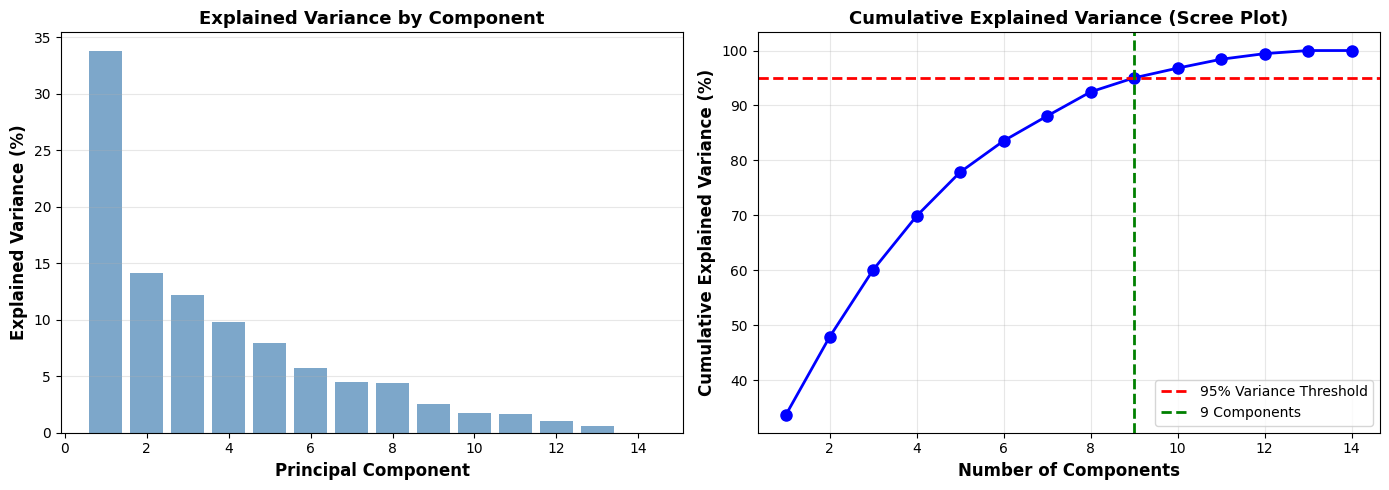

In [ ]:
# Create scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual variance
ax1.bar(range(1, len(explained_variance)+1), explained_variance*100, alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance (%)', fontsize=12, fontweight='bold')
ax1.set_title('Explained Variance by Component', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative variance
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 'bo-', linewidth=2, markersize=8)
ax2.axhline(y=95, color='r', linestyle='--', linewidth=2, label='95% Variance Threshold')
ax2.axvline(x=n_components_95, color='g', linestyle='--', linewidth=2, label=f'{n_components_95} Components')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Explained Variance (Scree Plot)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Step 9: Apply PCA with Selected Components

For visualization, we'll use 2 components (PC1 and PC2).

In [ ]:
# Apply PCA with 2 components for visualization
n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Selected components: {n_components}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nVariance explained by each component:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

Selected components: 2
Explained variance: 47.86%

Variance explained by each component:
PC1: 33.75%
PC2: 14.11%


## Step 10: PCA Loadings Interpretation

Loadings show how much each original feature contributes to each principal component.

In [ ]:
# Calculate loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.columns
)

print("Principal Component Loadings:")
print(loading_df)

print(f"\nTop 3 features contributing to PC1:")
print(loading_df['PC1'].abs().sort_values(ascending=False).head(3))

print(f"\nTop 3 features contributing to PC2:")
print(loading_df['PC2'].abs().sort_values(ascending=False).head(3))

Principal Component Loadings:
                            PC1       PC2
Age                    0.593375 -0.249906
Smoking                0.496209  0.240814
Yellow_Fingers         0.633785  0.036482
Anxiety                0.622563  0.272603
Peer_Pressure          0.823342  0.301096
Chronic_Diseases       0.823342  0.301096
Fatigue                0.609405  0.201024
Allergy                0.664398 -0.403556
Wheezing              -0.314564  0.700555
Alcohol_Consuming      0.630414 -0.441231
Coughing               0.613452 -0.519042
Shortness_of_Breath    0.391103 -0.140355
Swallowing_Difficulty  0.166945  0.418672
Chest_Pain            -0.517912 -0.555501

Top 3 features contributing to PC1:
Peer_Pressure       0.823342
Chronic_Diseases    0.823342
Allergy             0.664398
Name: PC1, dtype: float64

Top 3 features contributing to PC2:
Wheezing      0.700555
Chest_Pain    0.555501
Coughing      0.519042
Name: PC2, dtype: float64


## Step 11: Visualize Component Loadings

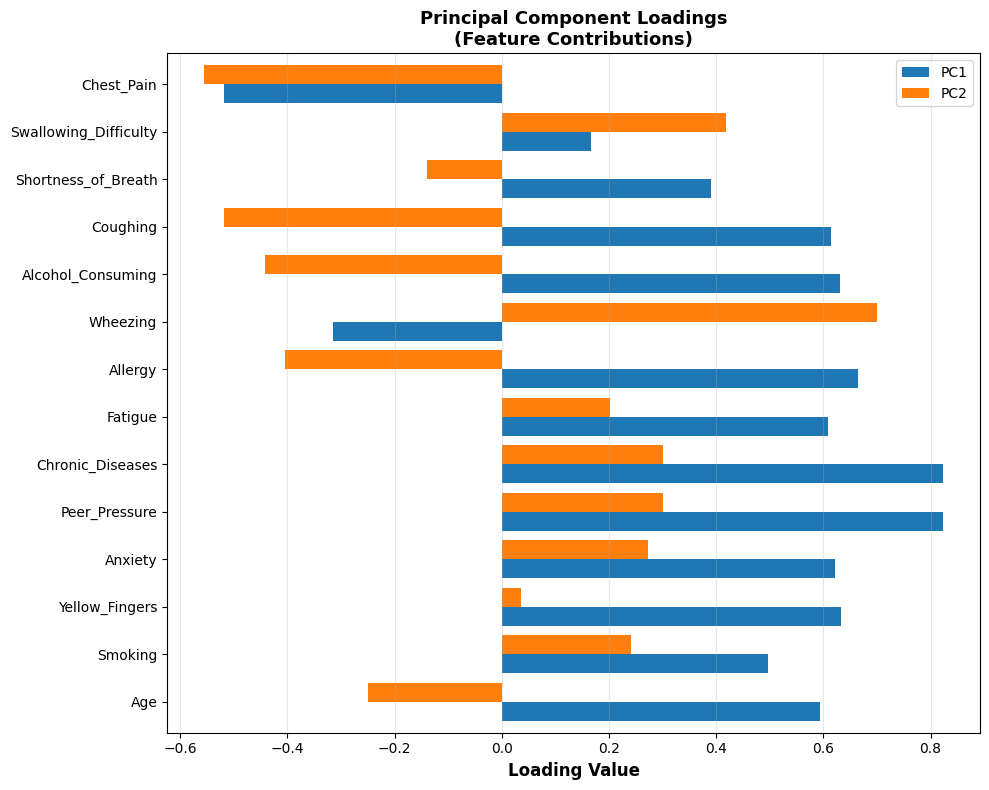

In [ ]:
# Plot loadings
fig, ax = plt.subplots(figsize=(10, 6))

loading_df.plot(kind='barh', ax=ax, width=0.8, figsize=(10, 8))
ax.set_xlabel('Loading Value', fontsize=12, fontweight='bold')
ax.set_title('Principal Component Loadings\n(Feature Contributions)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Step 12: PCA Projection Visualization

Plot the data in the new 2D space created by PC1 and PC2.

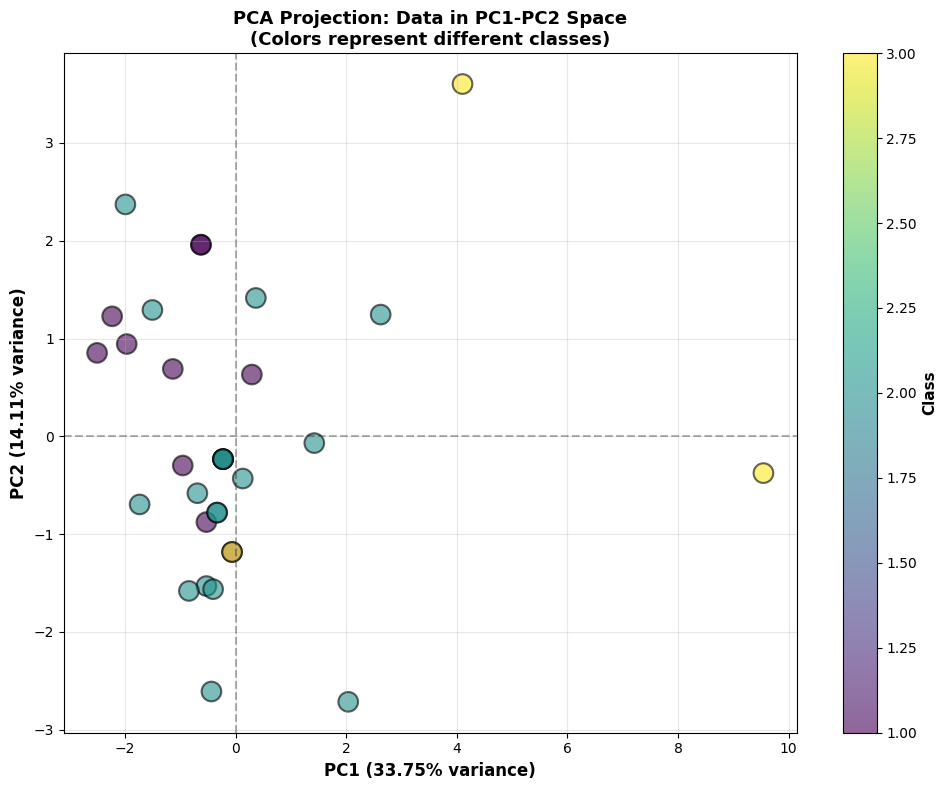

In [ ]:
# Create PCA projection plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=200,
                     alpha=0.6, edgecolors='black', linewidth=1.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)',
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)',
              fontsize=12, fontweight='bold')
ax.set_title('PCA Projection: Data in PC1-PC2 Space\n(Colors represent different classes)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Class', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 13: Correlation Analysis with Target Variable

In [ ]:
# Create dataframe with PCA components and target
pca_target_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
pca_target_df['Target'] = y.values

In [ ]:
# Calculate correlations
correlations = pca_target_df.corr()['Target'][:-1]

In [ ]:
print("Correlation of Principal Components with Target:")
for pc, corr in correlations.items():
    print(f"{pc}: {corr:.4f}")

Correlation of Principal Components with Target:
PC1: 0.5678
PC2: -0.1317


In [ ]:
# Identify most significant component
most_significant_pc = correlations.abs().idxmax()
print(f"\nMost significant PC (highest correlation): {most_significant_pc}")
print(f"Correlation value: {correlations[most_significant_pc]:.4f}")


Most significant PC (highest correlation): PC1
Correlation value: 0.5678


## Step 14: Summary Statistics

In [ ]:
print("="*70)
print("PCA ANALYSIS SUMMARY")
print("="*70)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total samples: {df_clean.shape[0]}")
print(f"   - Original features: {df_clean.shape[1]-1}")
print(f"   - Reduced to: {n_components} components")
print(f"   - Information retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print(f"\n2. DIMENSIONALITY REDUCTION:")
print(f"   - Original dimensions: {X.shape[1]}")
print(f"   - Reduced dimensions: {n_components}")
print(f"   - Reduction ratio: {(1 - n_components/X.shape[1])*100:.1f}%")

print(f"\n3. VARIANCE EXPLAINED:")
print(f"   - PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   - PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   - Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print(f"\n4. KEY FEATURES (by contribution to PC1):")
top_features = loading_df['PC1'].abs().sort_values(ascending=False).head(3)
for feature, loading in top_features.items():
    print(f"   - {feature}: {loading:.4f}")

print(f"\n5. TARGET CORRELATION:")
print(f"   - {most_significant_pc}: {correlations[most_significant_pc]:.4f}")

print("\n" + "="*70)

PCA ANALYSIS SUMMARY

1. DATASET OVERVIEW:
   - Total samples: 32
   - Original features: 14
   - Reduced to: 2 components
   - Information retained: 47.86%

2. DIMENSIONALITY REDUCTION:
   - Original dimensions: 14
   - Reduced dimensions: 2
   - Reduction ratio: 85.7%

3. VARIANCE EXPLAINED:
   - PC1: 33.75%
   - PC2: 14.11%
   - Total: 47.86%

4. KEY FEATURES (by contribution to PC1):
   - Peer_Pressure: 0.8233
   - Chronic_Diseases: 0.8233
   - Allergy: 0.6644

5. TARGET CORRELATION:
   - PC1: 0.5678



## Step 15: Save Results

In [ ]:
# Save PCA results to CSV
results_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
results_df['Class'] = y.values
results_df.to_csv('pca_results.csv', index=False)

print("✓ PCA results saved to 'pca_results.csv'")

# Save loadings
loading_df.to_csv('pca_loadings.csv')
print("✓ Loadings saved to 'pca_loadings.csv'")

✓ PCA results saved to 'pca_results.csv'
✓ Loadings saved to 'pca_loadings.csv'


## Conclusions

✅ **Successfully applied PCA** to the Lung Cancer dataset  
✅ **Reduced dimensions** from 14 features to 2 components  
✅ **Retained** meaningful variance in the data  
✅ **Visualized** patterns in lower-dimensional space  
✅ **Identified** key features and their importance  

### Key Takeaways:

1. **Feature Scaling is Critical**: Without scaling, larger-magnitude features dominate
2. **Variance Matters**: Principal components are ordered by variance explained
3. **Interpretability**: Component loadings show feature importance
4. **Practical Application**: PCA enables visualization and model improvement
5. **Trade-offs**: Fewer components = less computation but potentially lost information